# Primary analysis — dependence in SPF forecast errors

Exploratory look at the two dependence dimensions that the rank-CI pipeline has to handle:

| Dimension | Where it enters the pipeline | What we check |
|---|---|---|
| **Serial correlation** (within a forecaster, over time) | Newey–West / Bartlett HAC SE on each loss-difference series $d^{jk}_t$, Andrews bandwidth | ACF of signed errors $e_{jt}$, of losses $X_{jt}=e_{jt}^2$, and of the differences $d^{jk}_t = X_{jt}-X_{kt}$ |
| **Cross-sectional correlation** (across forecasters, same target) | Joint covariance of the $\hat\theta_j$ / of the $d^{jk}$ (MDS $\Sigma$ or direct $\Omega$) used for simulation | Pairwise correlation of errors and losses, Pesaran CD test, share of variance due to a common time effect, how much differencing cancels |

Panels are built exactly as in the CI notebooks (error = forecast − realization, realization = first release):

**Philadelphia Fed SPF** — survey-quarter panels, horizon `h=3` (one-quarter-ahead), RTDSM advance estimate:
`NGDP`, `RGDP` (levels, bn \$), `UNEMP` (pp), `PGDP` (index level, 1996+), `INFL` (annualized q/q inflation derived from PGDP, 1996+).
As a robustness check (Section 1.2) we also build `NGDP_g` / `RGDP_g`: the same forecasts converted to annualized
q/q growth rates, exactly like `INFL` is derived from `PGDP`. These are **not** the panels the CI notebooks rank on.

**ECB SPF** — annual target (`"YYYY"`), horizon `h=3` quarters (Q1 survey for the current calendar-year average), Eurostat realizations:
`HICP` (y/y %), `RGDP` (y/y %).

A horizon sweep at the end checks how both kinds of dependence change with the forecast horizon.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from rankci import ar1_coefficient, andrews_bandwidth
from rankci.data.philly import (
    load_spf, load_rtdsm, compute_errors,
    advance_vintage_col, HORIZON_OFFSETS,
)
from rankci.data.ecb import (
    load_ecb_spf, add_horizon,
    load_hicp_realized, hicp_realized_by_target_period,
    load_rgdp_index_sdmx, rgdp_yoy_from_index, rgdp_realized_by_target_period,
)

PHILLY = "../data/philly"
ECB    = "../data/ecb"

HORIZON_PHILLY = 3      # one-quarter-ahead, as in the Philly CI notebooks
HORIZON_ECB    = 3      # Q1 survey -> current-year annual average, as in the ECB CI notebooks
N_TOP          = 8      # top-N forecasters (by coverage) used in the CI notebooks
MIN_OBS        = {"philly": 20, "ecb": 15}
MAX_LAG        = 8
MIN_PAIRS      = 8      # minimum overlapping obs for a correlation to be reported

# Reference categorical slots (blue / orange / aqua) and recessive ink
C1, C2, C3 = "#2a78d6", "#eb6834", "#1baf7a"
INK2, GRID = "#52514e", "#e4e3df"
plt.rcParams.update({
    "figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "axes.edgecolor": INK2, "axes.labelcolor": INK2, "xtick.color": INK2,
    "ytick.color": INK2, "lines.linewidth": 1.6, "font.size": 9,
    "axes.prop_cycle": plt.cycler(color=["#2a78d6", "#eb6834", "#1baf7a", "#eda100",
                                         "#e87ba4", "#008300", "#4a3aa7", "#e34948"]),
})

## 1. Build the signed-error panels

Each panel is a wide `(time × forecaster)` DataFrame of **signed** errors on a *regular* time grid
(missing surveys are NaN rows, not dropped), so that lag-$k$ really means $k$ periods apart.
Losses are the squares; the CI notebooks rank on exactly these.

In [2]:
def _regular(wide, freq):
    # Re-index a wide panel onto a gap-free PeriodIndex.
    full = pd.period_range(wide.index.min(), wide.index.max(), freq=freq)
    return wide.reindex(full)


def philly_signed_panel(errors_df, err_col):
    w = errors_df.pivot_table(index=["YEAR", "QUARTER"], columns="ID", values=err_col)
    w.index = pd.PeriodIndex([pd.Period(year=y, quarter=q, freq="Q") for y, q in w.index])
    return _regular(w, "Q")


def ecb_signed_panel(long_df, realized, indicator, horizon_q, target_kind="year"):
    df = long_df[(long_df.indicator == indicator) & (long_df.target_kind == target_kind)
                 & (long_df.horizon_q == horizon_q) & long_df.point.notna()].copy()
    df["err"] = df.point - df.target_period.map(realized)
    df = df.dropna(subset=["err"])
    if df.empty:
        return pd.DataFrame()
    w = df.pivot_table(index="target_year", columns="forecaster_id", values="err", aggfunc="mean")
    w.index = pd.PeriodIndex([pd.Period(year=int(y), freq="Y") for y in w.index])
    return _regular(w, "Y")

### Philadelphia Fed

In [3]:
spf_ngdp = load_spf(f"{PHILLY}/SPFmicrodata.xlsx", sheet="NGDP")
spf_rgdp = load_spf(f"{PHILLY}/SPFmicrodata.xlsx", sheet="RGDP")
spf_unemp = load_spf(f"{PHILLY}/SPFmicrodata.xlsx", sheet="UNEMP")
spf_pgdp = load_spf(f"{PHILLY}/Individual_PGDP.xlsx", sheet="PGDP")
spf_pgdp = spf_pgdp[spf_pgdp.YEAR >= 1996].reset_index(drop=True)   # chain-weighted regime only

noutput = load_rtdsm(f"{PHILLY}/NOUTPUTQvQd.xlsx", prefix="NOUTPUT")
routput = load_rtdsm(f"{PHILLY}/ROUTPUTQvQd.xlsx", prefix="ROUTPUT")
ruc     = load_rtdsm(f"{PHILLY}/rucQvMd.xlsx", prefix="RUC", freq="monthly")
p_rtdsm = load_rtdsm(f"{PHILLY}/PQvQd.xlsx", prefix="P")

err_philly = {
    "NGDP":  compute_errors(spf_ngdp, noutput, indicator="NGDP"),
    "RGDP":  compute_errors(spf_rgdp, routput, indicator="RGDP"),
    "UNEMP": compute_errors(spf_unemp, ruc, indicator="UNEMP"),
    "PGDP":  compute_errors(spf_pgdp, p_rtdsm, indicator="PGDP"),
}

/Users/Parimah/Desktop/ranks-inference-forecasters/.venv/lib/python3.11/site-packages/openpyxl/worksheet/header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""Cannot parse header or footer so it will be ignored""")


/Users/Parimah/Desktop/ranks-inference-forecasters/.venv/lib/python3.11/site-packages/openpyxl/worksheet/header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""Cannot parse header or footer so it will be ignored""")


/Users/Parimah/Desktop/ranks-inference-forecasters/.venv/lib/python3.11/site-packages/openpyxl/worksheet/header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""Cannot parse header or footer so it will be ignored""")


/Users/Parimah/Desktop/ranks-inference-forecasters/.venv/lib/python3.11/site-packages/openpyxl/worksheet/header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""Cannot parse header or footer so it will be ignored""")


`INFL` uses the same derivation as `INFL_CI.ipynb`: forecast $\hat\pi_h = 100[(P_h/P_{h-1})^4-1]$ from the
forecaster's own price path; realized inflation from the advance vintage of the target, reading $P_t$ and $P_{t-1}$
from that single vintage column. The same transformation applied to NGDP / RGDP gives the growth-rate panels
`NGDP_g` / `RGDP_g`.

In [4]:
def _ann_growth(p_cur, p_prev):
    return 100.0 * ((p_cur / p_prev) ** 4 - 1.0)


def _realized_growth(ty, tq, rtdsm):
    col = advance_vintage_col(int(ty), int(tq), rtdsm.attrs.get("prefix", "P"))
    py, pq = (ty, tq - 1) if tq > 1 else (ty - 1, 4)
    try:
        p_t, p_p = rtdsm.loc[(int(ty), int(tq)), col], rtdsm.loc[(int(py), int(pq)), col]
    except KeyError:
        return np.nan
    return np.nan if (pd.isna(p_t) or pd.isna(p_p) or p_p <= 0) else _ann_growth(p_t, p_p)


def compute_growth_errors(df, rtdsm, indicator, name):
    # Annualized q/q growth errors for h = 2..6 (same-vintage realized growth).
    out = df[["YEAR", "QUARTER", "ID", "INDUSTRY"]].copy()
    for h in range(2, 7):
        total = (df.YEAR - 1) * 4 + (df.QUARTER - 1) + HORIZON_OFFSETS[h]
        ty, tq = (total // 4 + 1).astype(int), (total % 4 + 1).astype(int)
        realized = np.array([_realized_growth(y, q, rtdsm) for y, q in zip(ty, tq)])
        forecast = _ann_growth(df[f"{indicator}{h}"].values, df[f"{indicator}{h-1}"].values)
        out[f"error_{name}{h}"] = forecast - realized
    return out


err_philly["INFL"]   = compute_growth_errors(spf_pgdp, p_rtdsm, "PGDP", "INFL")
err_philly["NGDP_g"] = compute_growth_errors(spf_ngdp, noutput, "NGDP", "NGDP_g")
err_philly["RGDP_g"] = compute_growth_errors(spf_rgdp, routput, "RGDP", "RGDP_g")

### ECB

In [5]:
ecb_long = add_horizon(load_ecb_spf(f"{ECB}/individual_forecasts", indicators=["HICP", "RGDP"]))

hicp_real = hicp_realized_by_target_period(
    load_hicp_realized(f"{ECB}/prc_hicp_manr__custom_21709551_spreadsheet.xlsx"))
rgdp_idx = load_rgdp_index_sdmx(f"{ECB}/namq_10_gdp_EA_RGDP.xml", expected_dims={
    "unit": "CLV_I20", "na_item": "B1GQ", "s_adj": "SCA", "geo": "EA"})
rgdp_real = rgdp_realized_by_target_period(rgdp_yoy_from_index(rgdp_idx), annual_method="mean")
realized_ecb = {"HICP": hicp_real, "RGDP": rgdp_real}

/Users/Parimah/Desktop/ranks-inference-forecasters/.venv/lib/python3.11/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


In [6]:
def build_panels(h_philly=HORIZON_PHILLY, h_ecb=HORIZON_ECB):
    panels = {}
    for name, e in err_philly.items():
        col = f"error_{name}{h_philly}"
        if col in e:
            panels[f"Philly {name}"] = ("philly", philly_signed_panel(e, col))
    for name, real in realized_ecb.items() if h_ecb is not None else []:
        panels[f"ECB {name}"] = ("ecb", ecb_signed_panel(ecb_long, real, name, h_ecb))
    return panels


def eligible(E, source):
    # Forecasters with enough observations for per-series statistics.
    return E.loc[:, E.notna().sum() >= MIN_OBS[source]]


def top_n(E, source, n=N_TOP):
    # Same rule as select_top_forecasters: top-n by obs count among the eligible.
    E = eligible(E, source)
    return E[E.notna().sum().nlargest(n).index]


PANELS = build_panels()

overview = []
for name, (src, E) in PANELS.items():
    Ee, Et = eligible(E, src), top_n(E, src)
    overview.append({
        "panel": name, "freq": E.index.freqstr,
        "span": f"{E.index.min()} – {E.index.max()}", "T (grid)": len(E),
        "forecasters (all)": E.shape[1], f"≥ min_obs": Ee.shape[1],
        "top-N coverage %": round(100 * Et.notna().values.mean(), 1),
        "mean error (bias)": round(np.nanmean(E.values), 3),
        "sd error": round(np.nanstd(E.values), 3),
    })
pd.DataFrame(overview).set_index("panel")

,freq,span,T (grid),forecasters (all),≥ min_obs,top-N coverage %,mean error (bias),sd error
panel,,,,,,,,
Philly NGDP,Q-DEC,1968Q4 – 2025Q1,226,345,148,51.7,-20.432,258.477
Philly RGDP,Q-DEC,1968Q4 – 2025Q1,226,352,147,51.9,-94.767,435.093
Philly UNEMP,Q-DEC,1968Q4 – 2025Q3,228,353,151,52.5,0.042,0.879
Philly PGDP,Q-DEC,1996Q1 – 2025Q4,120,153,70,83.3,0.840,3.282
Philly INFL,Q-DEC,1996Q1 – 2025Q4,120,153,70,83.3,-0.027,1.507
Philly NGDP_g,Q-DEC,1968Q4 – 2025Q1,226,345,148,51.7,0.256,4.564
Philly RGDP_g,Q-DEC,1968Q4 – 2025Q1,226,352,147,51.9,0.333,4.158
ECB HICP,Y-DEC,1999 – 2025,27,112,58,98.6,-0.320,1.180
ECB RGDP,Y-DEC,1999 – 2025,27,112,58,98.6,0.171,1.820


### 1.1 Errors over time

Grey lines: individual top-N forecasters. Blue: consensus (cross-sectional mean of all available forecasters).
When individual errors track the consensus closely, the cross-sectional correlation will be high — a common
macro shock that nobody predicted hits everyone's error at once.

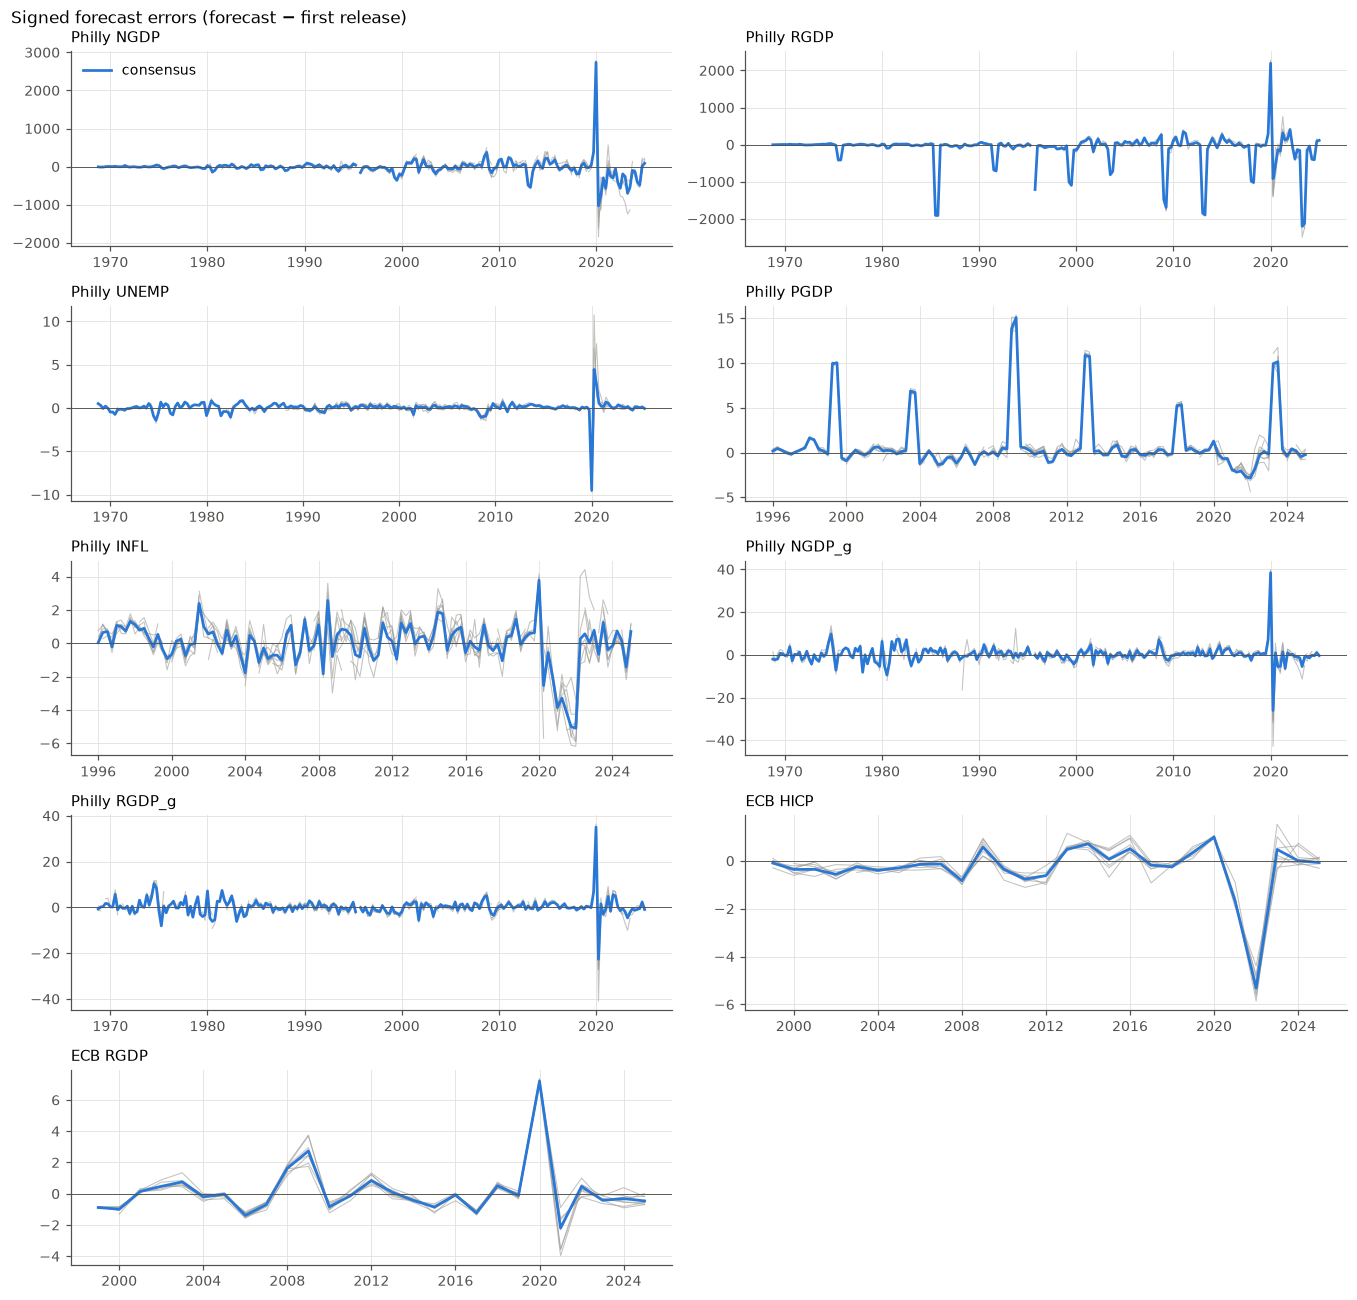

In [7]:
def grid_axes(n, ncols=2, h=2.4, w=6.2):
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(w * ncols, h * nrows), squeeze=False)
    for ax in axes.flat[n:]:
        ax.set_visible(False)
    return fig, axes.flat


fig, axes = grid_axes(len(PANELS))
for ax, (name, (src, E)) in zip(axes, PANELS.items()):
    t = E.index.to_timestamp()
    for c in top_n(E, src).columns:
        ax.plot(t, E[c], color="#9c9b97", lw=0.7, alpha=0.6)
    ax.plot(t, E.mean(axis=1), color=C1, lw=1.8, label="consensus")
    ax.axhline(0, color=INK2, lw=0.6)
    ax.set_title(name, loc="left", fontsize=10)
axes[0].legend(frameon=False, loc="upper left")
fig.suptitle("Signed forecast errors (forecast − first release)", x=0.01, ha="left")
fig.tight_layout()
plt.show()

### 1.2 Level panels carry base-year artifacts

`NGDP`, `RGDP` and `PGDP` are forecast in **levels**. When the BEA rebases or benchmark-revises the series between
the survey (forecasts made on the old base) and the advance release of the target (new base), every forecaster's
level error jumps by the same amount. Those are the recurring ±1000–2000 bn spikes in `RGDP` and the +5…+15
index-point spikes in `PGDP` above. Each event spans **two consecutive surveys**, which mechanically produces

* a cross-sectional correlation near 1 (a common shift of the same size for everybody), and
* a lag-1 autocorrelation (two adjacent spikes).

Level errors also scale with the level of GDP, so their variance trends upward over the sample — non-stationary
variance in the loss series, i.e. the regime where the direct-$\Omega$ covariance matters.

The table lists survey quarters whose consensus error is an extreme outlier (robust z > 10). The growth-rate panels
`NGDP_g` / `RGDP_g` are the base-free comparison and are carried through every table below.

In [8]:
spikes = {}
for name in ["NGDP", "RGDP", "PGDP", "NGDP_g", "RGDP_g", "INFL"]:
    cons = PANELS[f"Philly {name}"][1].mean(axis=1)
    dev = (cons - cons.median()).abs()
    z = dev / (1.4826 * dev.median())
    spikes[name] = z[z > 10].index.astype(str).tolist()
pd.DataFrame({"n spikes": {k: len(v) for k, v in spikes.items()},
              "survey quarters (|robust z| > 10)": {k: ", ".join(v) for k, v in spikes.items()}})

,n spikes,survey quarters (|robust z| > 10)
NGDP,6,"2020Q1, 2020Q2, 2020Q3, 2021Q1, 2022Q3, 2023Q2"
RGDP,20,"1985Q3, 1985Q4, 1991Q3, 1991Q4, 1995Q4, 1999Q2..."
PGDP,10,"1999Q2, 1999Q3, 2003Q3, 2003Q4, 2009Q1, 2009Q2..."
NGDP_g,2,"2020Q1, 2020Q2"
RGDP_g,2,"2020Q1, 2020Q2"
INFL,0,


## 2. Serial correlation

Autocorrelations are computed **gap-aware**: $\hat\rho_k$ uses every pair $(t, t+k)$ for which both values are
observed, normalised by the full-sample variance. With $n_k$ such pairs, $\pm 1.96/\sqrt{n_k}$ is the white-noise band,
and the Box–Pierce statistic $Q = \sum_{k=1}^{K} n_k\hat\rho_k^2 \sim \chi^2_K$ tests joint whiteness up to lag $K$.

*What to expect.* Under rational expectations a forecast for $t+1$ made in quarter $t$ is not informed of the
error made at $t$ (first release of $t$ arrives in $t+1$), so one-quarter-ahead errors can be MA(1) even under
efficiency — a non-zero lag-1 is not by itself evidence of irrationality, but it **is** what the HAC has to absorb.
ECB annual targets at the Q1 survey do not overlap from year to year, so lag-1 there is a genuine persistence of
errors across years.

In [9]:
def acf_gap(x, nlags=MAX_LAG, min_pairs=MIN_PAIRS):
    # Gap-aware ACF. Returns (rho[1..nlags], n_pairs[1..nlags]).
    x = np.asarray(x, float)
    xc = x - np.nanmean(x)
    v = np.nanmean(xc ** 2)
    rho, npairs = np.full(nlags, np.nan), np.zeros(nlags, int)
    for k in range(1, nlags + 1):
        a, b = xc[k:], xc[:-k]
        ok = ~np.isnan(a) & ~np.isnan(b)
        npairs[k - 1] = ok.sum()
        if ok.sum() >= min_pairs and v > 0:
            rho[k - 1] = np.mean(a[ok] * b[ok]) / v
    return rho, npairs


def box_pierce(rho, npairs, K):
    ok = ~np.isnan(rho[:K])
    if not ok.any():
        return np.nan
    Q = np.sum(npairs[:K][ok] * rho[:K][ok] ** 2)
    return stats.chi2.sf(Q, ok.sum())


def serial_summary(E, src, transform=lambda x: x, K=4):
    E = eligible(E, src)
    rows = []
    for c in E.columns:
        rho, npairs = acf_gap(transform(E[c].values))
        rows.append({"id": c, "rho1": rho[0], "rho2": rho[1],
                     "sig1": abs(rho[0]) > 1.96 / np.sqrt(max(npairs[0], 1)),
                     "p_BP": box_pierce(rho, npairs, K)})
    return pd.DataFrame(rows), E


K_BP = {"Q": 4, "Y": 2}   # Box–Pierce lags: one year of quarters / two years

In [10]:
def serial_table(transform, label):
    out = []
    for name, (src, E) in PANELS.items():
        s, Ee = serial_summary(E, src, transform, K=K_BP[E.index.freqstr[0]])
        rho_cons, _ = acf_gap(transform(E.mean(axis=1).values))
        out.append({
            "panel": name, "n forecasters": len(s),
            "median ρ1": s.rho1.median(), "IQR ρ1": f"[{s.rho1.quantile(.25):.2f}, {s.rho1.quantile(.75):.2f}]",
            "median ρ2": s.rho2.median(),
            "% ρ1 significant": 100 * s.sig1.mean(),
            "% BP p<0.05": 100 * (s.p_BP < 0.05).mean(),
            "consensus ρ1": rho_cons[0],
        })
    t = pd.DataFrame(out).set_index("panel").round(2)
    t.columns.name = label
    return t


serial_table(lambda x: x, "signed errors e")

signed errors e,n forecasters,median ρ1,IQR ρ1,median ρ2,% ρ1 significant,% BP p<0.05,consensus ρ1
panel,,,,,,,
Philly NGDP,148,0.33,"[0.12, 0.48]",-0.04,43.24,34.46,0.13
Philly RGDP,147,0.40,"[0.20, 0.54]",-0.06,62.59,44.22,0.39
Philly UNEMP,151,0.34,"[0.06, 0.54]",0.03,54.97,34.44,-0.09
Philly PGDP,70,0.50,"[0.44, 0.54]",-0.03,82.86,60.00,0.49
Philly INFL,70,0.22,"[0.04, 0.45]",0.22,42.86,44.29,0.40
Philly NGDP_g,148,0.10,"[-0.08, 0.27]",0.03,29.05,14.86,-0.12
Philly RGDP_g,147,0.09,"[-0.09, 0.27]",0.00,29.25,10.88,-0.10
ECB HICP,58,0.10,"[-0.10, 0.21]",-0.32,3.45,0.00,0.10
ECB RGDP,58,-0.22,"[-0.31, -0.12]",-0.02,1.72,0.00,-0.21


In [11]:
serial_table(lambda x: x ** 2, "losses X = e²")

losses X = e²,n forecasters,median ρ1,IQR ρ1,median ρ2,% ρ1 significant,% BP p<0.05,consensus ρ1
panel,,,,,,,
Philly NGDP,148,0.27,"[0.06, 0.49]",0.06,40.54,31.08,0.16
Philly RGDP,147,0.39,"[0.10, 0.54]",-0.06,60.54,43.54,0.41
Philly UNEMP,151,0.23,"[0.06, 0.42]",0.05,33.11,23.84,0.22
Philly PGDP,70,0.48,"[0.43, 0.51]",-0.09,80.00,61.43,0.46
Philly INFL,70,0.25,"[0.04, 0.55]",0.13,45.71,41.43,0.66
Philly NGDP_g,148,0.14,"[0.01, 0.36]",0.02,25.68,19.59,0.40
Philly RGDP_g,147,0.16,"[-0.01, 0.37]",0.00,27.89,23.81,0.38
ECB HICP,58,0.06,"[0.01, 0.14]",-0.05,1.72,1.72,0.05
ECB RGDP,58,0.02,"[-0.02, 0.06]",-0.09,0.00,0.00,0.02


### 2.1 ACF profiles

Median ACF across eligible forecasters (line) with the inter-quartile band, lags 1–8 (quarters for Philly, years
for ECB). Dashed grey: typical white-noise band $\pm1.96/\sqrt{\bar n}$.

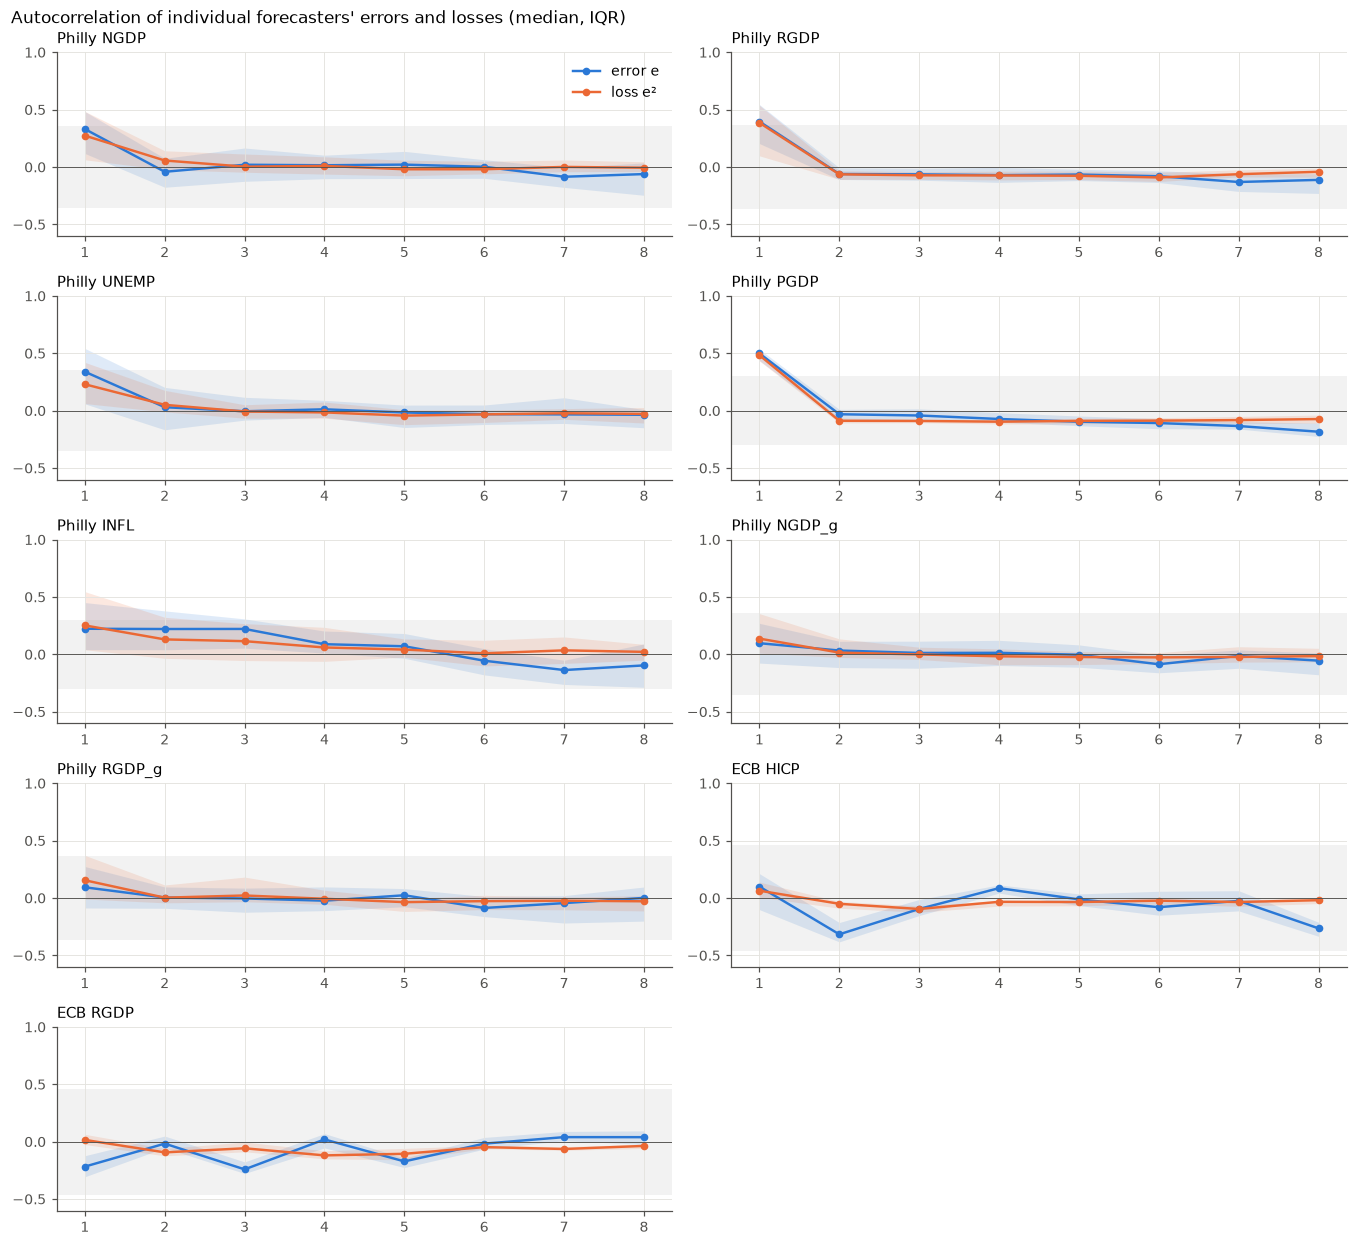

In [12]:
def acf_matrix(E, src, transform):
    E = eligible(E, src)
    R, N = zip(*(acf_gap(transform(E[c].values)) for c in E.columns))
    return np.array(R), np.array(N)


fig, axes = grid_axes(len(PANELS), h=2.3)
lags = np.arange(1, MAX_LAG + 1)
for ax, (name, (src, E)) in zip(axes, PANELS.items()):
    for transform, col, lab in [(lambda x: x, C1, "error e"), (lambda x: x ** 2, C2, "loss e²")]:
        R, N = acf_matrix(E, src, transform)
        med = np.nanmedian(R, axis=0)
        ax.fill_between(lags, np.nanpercentile(R, 25, axis=0), np.nanpercentile(R, 75, axis=0),
                        color=col, alpha=0.15, lw=0)
        ax.plot(lags, med, color=col, marker="o", ms=4, label=lab)
    band = 1.96 / np.sqrt(np.nanmedian(N[:, 0]))
    ax.axhspan(-band, band, color="#9c9b97", alpha=0.12, lw=0)
    ax.axhline(0, color=INK2, lw=0.6)
    ax.set_title(name, loc="left", fontsize=10)
    ax.set_xticks(lags)
    ax.set_ylim(-0.6, 1)
axes[0].legend(frameon=False)
fig.suptitle("Autocorrelation of individual forecasters' errors and losses (median, IQR)", x=0.01, ha="left")
fig.tight_layout()
plt.show()

### 2.2 Loss differentials — what the HAC actually sees

The NW standard errors are computed on $d^{jk}_t = X_{jt} - X_{kt}$ over each pair's overlap (compressed, as in
`compute_pairwise`). Below: the AR(1) coefficient of each top-N pair's difference series and the Andrews (1991)
Bartlett bandwidth it implies — i.e. how many lags the HAC is actually using.

In [13]:
def diff_series_stats(E, src):
    X = top_n(E, src) ** 2
    cols, rows = X.columns, []
    for i in range(len(cols)):
        for j in range(i + 1, len(cols)):
            d = (X[cols[i]] - X[cols[j]]).dropna().values
            if len(d) < MIN_PAIRS:
                continue
            rows.append({"n_overlap": len(d), "rho_d": ar1_coefficient(d), "L_andrews": andrews_bandwidth(d)})
    return pd.DataFrame(rows)


diff_stats = {}
tab = []
for name, (src, E) in PANELS.items():
    s = diff_series_stats(E, src)
    diff_stats[name] = s
    tab.append({"panel": name, "pairs": len(s), "median overlap": s.n_overlap.median(),
                "median ρ(d)": s.rho_d.median(), "max ρ(d)": s.rho_d.max(),
                "% |ρ(d)|>0.2": 100 * (s.rho_d.abs() > 0.2).mean(),
                "median L": s.L_andrews.median(), "max L": s.L_andrews.max()})
pd.DataFrame(tab).set_index("panel").round(2)

,pairs,median overlap,median ρ(d),max ρ(d),% |ρ(d)|>0.2,median L,max L
panel,,,,,,,
Philly NGDP,28,61.5,0.11,0.48,57.14,3.0,6
Philly RGDP,28,62.0,0.00,0.38,39.29,1.0,4
Philly UNEMP,28,90.0,0.01,0.36,25.00,2.0,6
Philly PGDP,28,84.5,0.08,0.48,25.00,1.5,5
Philly INFL,28,84.5,0.27,0.57,75.00,3.5,7
Philly NGDP_g,28,61.5,0.07,0.38,25.00,1.0,4
Philly RGDP_g,28,62.0,-0.03,0.33,28.57,1.0,4
ECB HICP,28,26.0,-0.13,0.47,46.43,1.0,4
ECB RGDP,28,26.0,-0.06,0.27,25.00,1.0,3


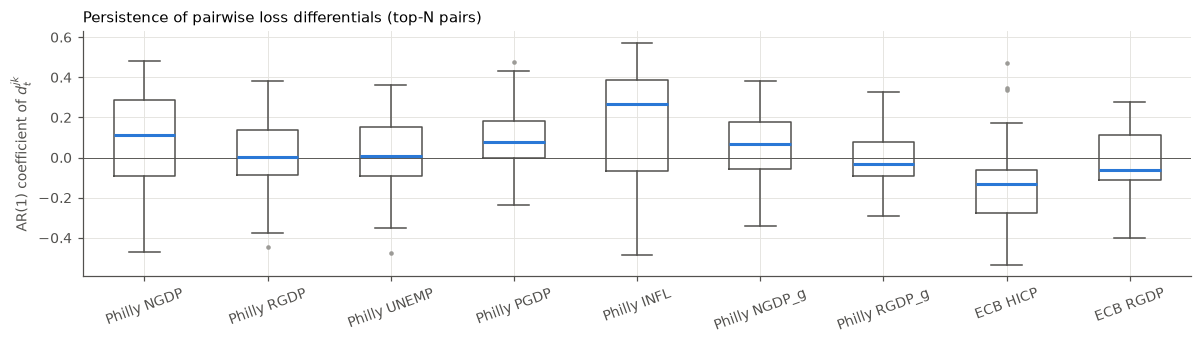

In [14]:
fig, ax = plt.subplots(figsize=(11, 3.2))
names = list(diff_stats)
data = [diff_stats[n].rho_d.values for n in names]
ax.boxplot(data, widths=0.5, showfliers=True,
           medianprops=dict(color=C1, lw=2), boxprops=dict(color=INK2),
           whiskerprops=dict(color=INK2), capprops=dict(color=INK2),
           flierprops=dict(marker="o", ms=3, mfc="#9c9b97", mec="none"))
ax.set_xticks(range(1, len(names) + 1), names, rotation=20)
ax.axhline(0, color=INK2, lw=0.6)
ax.set_ylabel(r"AR(1) coefficient of $d^{jk}_t$")
ax.set_title("Persistence of pairwise loss differentials (top-N pairs)", loc="left", fontsize=10)
fig.tight_layout()
plt.show()

## 3. Cross-sectional correlation

For each pair of forecasters $(j,k)$ we compute the Pearson correlation of their errors on the periods both
reported (requiring at least `MIN_PAIRS` overlapping observations). Summaries:

* **mean ρ** — average off-diagonal correlation, for signed errors and for squared losses.
* **Pesaran CD** (unbalanced version, Pesaran 2015): $CD = P^{-1/2}\sum_{j<k}\sqrt{T_{jk}}\,\hat\rho_{jk}$ over the
  $P$ valid pairs; $\approx N(0,1)$ under cross-sectional independence.
* **Time-effect $R^2$** — share of the pooled variance of $e_{jt}$ explained by a common period mean $\bar e_t$
  (one-way decomposition $e_{jt} = \bar e_t + u_{jt}$). Under no common component it would be about
  $T/\text{\#obs}$ (shown as *null R²*).
* **Differencing cancellation** — for the loss differences the rank CI uses,
  $1 - \operatorname{Var}(X_j - X_k)\,/\,[\operatorname{Var}X_j + \operatorname{Var}X_k] = 2\operatorname{Cov}/(\operatorname{Var}_j+\operatorname{Var}_k)$:
  the fraction of the losses' variance that cancels when we difference. High cancellation is what makes paired
  comparisons sharp (cf. the M-competition regime); low cancellation means the common shock passes into $d^{jk}$.

In [15]:
def pair_corr(E, min_pairs=MIN_PAIRS):
    # Pairwise-complete correlation matrix plus overlap counts.
    C = E.corr(min_periods=min_pairs)
    M = E.notna().astype(int)
    T = M.T @ M
    return C, T


def pesaran_cd(C, T):
    iu = np.triu_indices_from(C.values, k=1)
    r, t = C.values[iu], T.values[iu]
    ok = ~np.isnan(r)
    if ok.sum() == 0:
        return np.nan, np.nan
    cd = np.sum(np.sqrt(t[ok]) * r[ok]) / np.sqrt(ok.sum())
    return cd, 2 * stats.norm.sf(abs(cd))


def time_effect_r2(E):
    E = E.loc[E.notna().sum(axis=1) >= 2]
    v = E.values
    sst = np.nansum((v - np.nanmean(v)) ** 2)
    ssw = np.nansum((v - np.nanmean(v, axis=1, keepdims=True)) ** 2)
    n_obs = np.isfinite(v).sum()
    return 1 - ssw / sst, len(E) / n_obs


def cancellation(E):
    X = E ** 2
    cols, out = X.columns, []
    for i in range(len(cols)):
        for j in range(i + 1, len(cols)):
            xy = X[[cols[i], cols[j]]].dropna()
            if len(xy) < MIN_PAIRS:
                continue
            vj, vk = xy.var().values
            out.append(1 - (xy.iloc[:, 0] - xy.iloc[:, 1]).var() / (vj + vk))
    return np.array(out)


def offdiag(C):
    return C.values[np.triu_indices_from(C.values, k=1)]


cs = []
for name, (src, E) in PANELS.items():
    Ee, Et = eligible(E, src), top_n(E, src)
    C_e, T_e = pair_corr(Ee)
    C_x, T_x = pair_corr(Ee ** 2)
    cd_e, p_e = pesaran_cd(C_e, T_e)
    cd_x, p_x = pesaran_cd(C_x, T_x)
    r2, r2_null = time_effect_r2(Ee)
    canc = cancellation(Et)
    cs.append({
        "panel": name, "N": Ee.shape[1],
        "mean ρ (e)": np.nanmean(offdiag(C_e)), "% ρ(e)>0.5": 100 * np.mean(offdiag(C_e)[~np.isnan(offdiag(C_e))] > 0.5),
        "CD (e)": cd_e, "p CD (e)": p_e,
        "mean ρ (e²)": np.nanmean(offdiag(C_x)), "CD (e²)": cd_x, "p CD (e²)": p_x,
        "time-effect R²": r2, "null R²": r2_null,
        "top-N mean ρ (e)": np.nanmean(offdiag(pair_corr(Et)[0])),
        "top-N cancellation": np.nanmedian(canc),
    })
cs_table = pd.DataFrame(cs).set_index("panel")
cs_table.round(3)

,N,mean ρ (e),% ρ(e)>0.5,CD (e),p CD (e),mean ρ (e²),CD (e²),p CD (e²),time-effect R²,null R²,top-N mean ρ (e),top-N cancellation
panel,,,,,,,,,,,,
Philly NGDP,148,0.775,90.219,254.619,0.0,0.694,231.939,0.0,0.892,0.032,0.913,0.906
Philly RGDP,147,0.919,96.687,300.541,0.0,0.891,294.234,0.0,0.980,0.032,0.991,0.998
Philly UNEMP,151,0.759,90.397,250.112,0.0,0.648,218.450,0.0,0.819,0.032,0.808,0.815
Philly PGDP,70,0.965,99.433,231.740,0.0,0.966,232.460,0.0,0.982,0.031,0.989,0.993
Philly INFL,70,0.747,90.562,179.930,0.0,0.576,141.556,0.0,0.744,0.031,0.839,0.765
Philly NGDP_g,148,0.737,87.367,242.255,0.0,0.645,216.003,0.0,0.817,0.032,0.852,0.747
Philly RGDP_g,147,0.771,90.956,253.686,0.0,0.680,225.604,0.0,0.814,0.032,0.901,0.807
ECB HICP,58,0.888,98.582,146.985,0.0,0.817,136.206,0.0,0.928,0.022,0.955,0.975
ECB RGDP,58,0.965,99.939,160.191,0.0,0.965,160.344,0.0,0.962,0.022,0.967,0.981


### 3.1 Is it just a few extreme periods?

Pearson correlations of squared errors are dominated by a handful of shocks (COVID 2020, the 2021–22 inflation
surge, the base-year spikes in the level panels). Two checks: **Spearman** rank correlation, which is insensitive to the
size of the spikes, and dropping **2020–2021** (Philly: survey quarters; ECB: target years). The serial lag-1
autocorrelation is recomputed on the same trimmed sample.

In [16]:
def drop_covid(E):
    E = E.copy()
    E.loc[(E.index.year >= 2020) & (E.index.year <= 2021)] = np.nan   # keep the grid regular
    return E


rob = []
for name, (src, E) in PANELS.items():
    Ee, Ec = eligible(E, src), drop_covid(eligible(E, src))
    rob.append({
        "panel": name,
        "mean ρ (e) Pearson": np.nanmean(offdiag(pair_corr(Ee)[0])),
        "mean ρ (e) Spearman": np.nanmean(offdiag(Ee.corr(method="spearman", min_periods=MIN_PAIRS))),
        "mean ρ (e) ex-2020/21": np.nanmean(offdiag(pair_corr(Ec)[0])),
        "mean ρ (e²) Pearson": np.nanmean(offdiag(pair_corr(Ee ** 2)[0])),
        "mean ρ (e²) Spearman": np.nanmean(offdiag((Ee ** 2).corr(method="spearman", min_periods=MIN_PAIRS))),
        "mean ρ (e²) ex-2020/21": np.nanmean(offdiag(pair_corr(Ec ** 2)[0])),
        "median ρ1 (e) full": serial_summary(E, src)[0].rho1.median(),
        "median ρ1 (e) ex-2020/21": serial_summary(drop_covid(E), src)[0].rho1.median(),
    })
pd.DataFrame(rob).set_index("panel").round(2)

,mean ρ (e) Pearson,mean ρ (e) Spearman,mean ρ (e) ex-2020/21,mean ρ (e²) Pearson,mean ρ (e²) Spearman,mean ρ (e²) ex-2020/21,median ρ1 (e) full,median ρ1 (e) ex-2020/21
panel,,,,,,,,
Philly NGDP,0.77,0.71,0.76,0.69,0.55,0.67,0.33,0.46
Philly RGDP,0.92,0.80,0.92,0.89,0.64,0.90,0.40,0.48
Philly UNEMP,0.76,0.67,0.73,0.65,0.49,0.59,0.34,0.45
Philly PGDP,0.97,0.78,0.97,0.97,0.61,0.97,0.50,0.48
Philly INFL,0.75,0.72,0.71,0.58,0.44,0.55,0.22,0.06
Philly NGDP_g,0.74,0.69,0.72,0.64,0.47,0.62,0.10,0.19
Philly RGDP_g,0.77,0.71,0.76,0.68,0.53,0.66,0.09,0.21
ECB HICP,0.89,0.79,0.87,0.82,0.62,0.76,0.10,-0.04
ECB RGDP,0.97,0.91,0.91,0.97,0.80,0.85,-0.22,0.14


### 3.2 Correlation heatmaps (top-N forecasters)

Signed errors (top row of each pair) vs. squared losses. Diverging scale centred at zero; blank cells have fewer
than `MIN_PAIRS` overlapping periods.

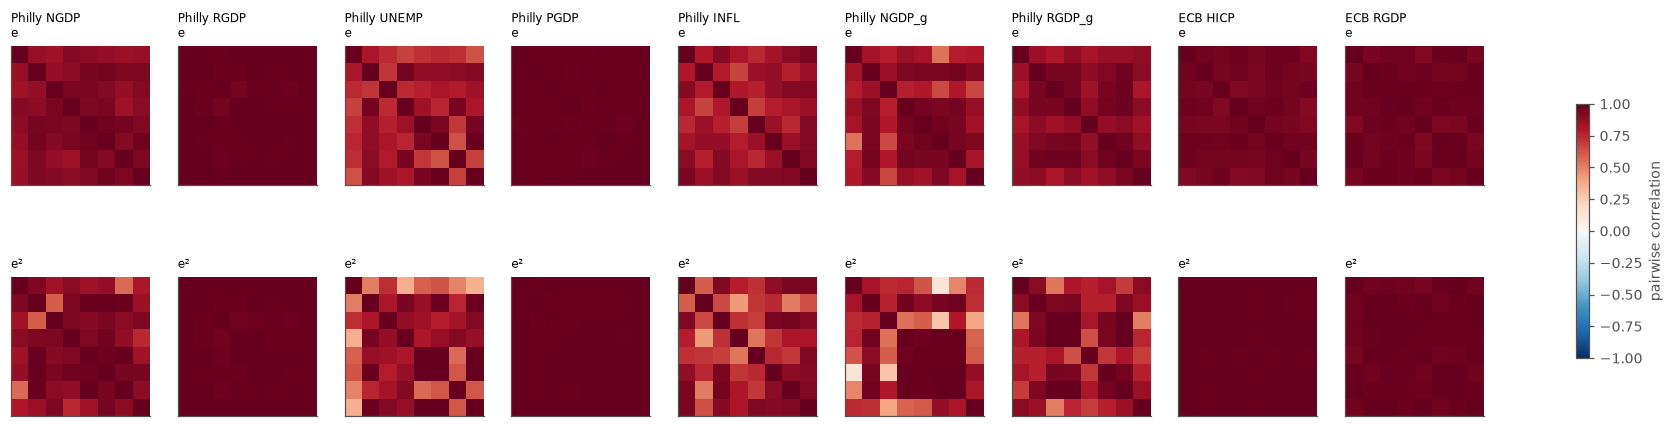

In [17]:
n = len(PANELS)
fig, axes = plt.subplots(2, n, figsize=(2.4 * n, 5.0), squeeze=False)
for col, (name, (src, E)) in enumerate(PANELS.items()):
    Et = top_n(E, src)
    for row, (M, lab) in enumerate([(Et, "e"), (Et ** 2, "e²")]):
        C, _ = pair_corr(M)
        ax = axes[row, col]
        im = ax.imshow(C.values, cmap="RdBu_r", vmin=-1, vmax=1)
        ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
        ax.set_title(f"{name}\n{lab}" if row == 0 else lab, fontsize=8, loc="left")
fig.colorbar(im, ax=axes, shrink=0.6, label="pairwise correlation")
plt.show()

### 3.3 Distribution of pairwise correlations (all eligible forecasters)

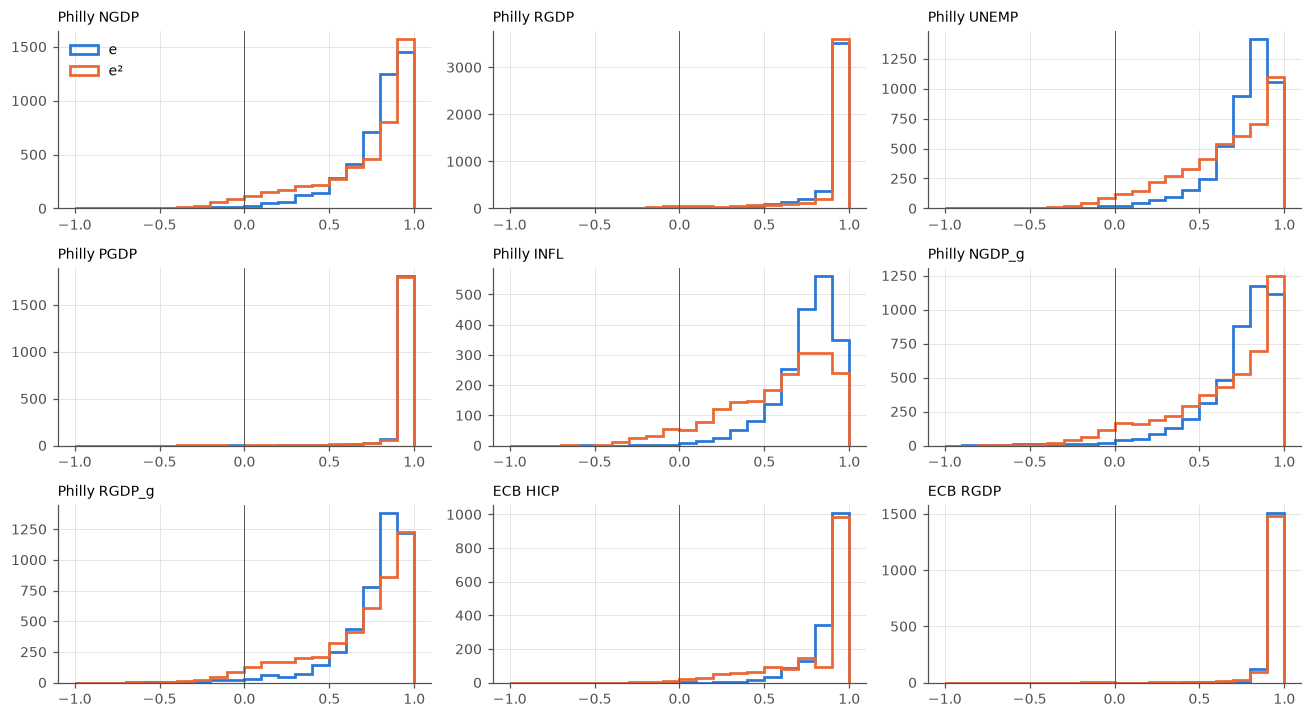

In [18]:
fig, axes = grid_axes(len(PANELS), ncols=3, h=2.2, w=4.0)
bins = np.linspace(-1, 1, 21)
for ax, (name, (src, E)) in zip(axes, PANELS.items()):
    Ee = eligible(E, src)
    for M, colr, lab in [(Ee, C1, "e"), (Ee ** 2, C2, "e²")]:
        r = offdiag(pair_corr(M)[0])
        ax.hist(r[~np.isnan(r)], bins=bins, color=colr, histtype="step", linewidth=1.8, label=lab)
    ax.axvline(0, color=INK2, lw=0.6)
    ax.set_xticks([-1, -0.5, 0, 0.5, 1])
    ax.set_title(name, loc="left", fontsize=9)
axes[0].legend(frameon=False)
fig.tight_layout()
plt.show()

### 3.4 Does the common shock cancel in squared-error differences?

The framework's additive decomposition $X_{t,j} = c_t + \varepsilon_{t,j}$ makes the common shock cancel exactly in
$d^{jk}_t$. For squared errors the common component sits in the *error*, not the loss: with
$e_{jt} = f_t + u_{jt}$,
$$
d^{jk}_t = e_{jt}^2 - e_{kt}^2 = (u_{jt}^2 - u_{kt}^2) + 2 f_t\,(u_{jt} - u_{kt}),
$$
so $f_t$ drops out of the level but re-enters as a **scale factor**: the variance of $d^{jk}_t$ is larger in periods
with a large common error. We check this by comparing the cross-pair mean of $(d^{jk}_t)^2$ in the 10 % of periods
with the largest squared consensus error $\bar e_t^{\,2}$ against the remaining periods (top-N pairs), and by the
rank correlation between $\bar e_t^{\,2}$ and that cross-pair mean. The ratio is driven by COVID, so it is repeated
without 2020–21; the rank correlation is the robust summary.

In [19]:
def shock_reentry(E, src, top_frac=0.10):
    Et = top_n(E, src)
    X = Et ** 2
    cols = X.columns
    D = pd.concat([X[cols[i]] - X[cols[j]] for i in range(len(cols)) for j in range(i + 1, len(cols))], axis=1)
    v_t = (D ** 2).mean(axis=1)                 # cross-pair mean of d_t^2 (NaN-skipping)
    f2 = E.mean(axis=1) ** 2                    # squared consensus error
    ok = v_t.notna() & f2.notna()
    v_t, f2 = v_t[ok], f2[ok]
    hi = f2 >= f2.quantile(1 - top_frac)
    return {"periods": int(ok.sum()),
            "variance ratio (shock / other)": v_t[hi].mean() / v_t[~hi].mean(),
            "share of Σd² in shock periods": v_t[hi].sum() / v_t.sum(),
            "Spearman(ē², mean d²)": stats.spearmanr(f2, v_t).statistic}


reentry = pd.DataFrame({name: shock_reentry(E, src) for name, (src, E) in PANELS.items()}).T
reentry_ex = pd.DataFrame({name: shock_reentry(drop_covid(E), src) for name, (src, E) in PANELS.items()}).T
pd.concat({"full sample": reentry, "ex-2020/21": reentry_ex}, axis=1).round(2)

full sample                                 \
                  periods variance ratio (shock / other)   
Philly NGDP         202.0                         234.30   
Philly RGDP         201.0                         227.26   
Philly UNEMP        175.0                        4661.43   
Philly PGDP         118.0                         228.85   
Philly INFL         118.0                          22.20   
Philly NGDP_g       202.0                          44.41   
Philly RGDP_g       201.0                         637.47   
ECB HICP             27.0                         129.17   
ECB RGDP             27.0                         187.99   

                                                                  ex-2020/21  \
              share of Σd² in shock periods Spearman(ē², mean d²)    periods   
Philly NGDP                            0.96                  0.76      194.0   
Philly RGDP                            0.96                  0.87      193.0   
Philly UNEMP                           1.00                  0.71      195.0   
Philly PGDP                            0.96                  0.73      110.0   
Philly INFL                            0.72                  0.69      110.0   
Philly NGDP_g                          0.84                  0.68      194.0   
Philly RGDP_g                          0.99                  0.73      193.0   
ECB HICP                               0.94                  0.63       25.0   
ECB RGDP                               0.96                  0.89       25.0   

                                                                            \
              variance ratio (shock / other) share of Σd² in shock periods   
Philly NGDP                            95.75                          0.92   
Philly RGDP                           644.61                          0.99   
Philly UNEMP                           23.41                          0.73   
Philly PGDP                           249.85                          0.97   
Philly INFL                             6.94                          0.44   
Philly NGDP_g                           3.85                          0.31   
Philly RGDP_g                          20.92                          0.71   
ECB HICP                              125.26                          0.94   
ECB RGDP                               82.53                          0.92   

                                     
              Spearman(ē², mean d²)  
Philly NGDP                    0.74  
Philly RGDP                    0.86  
Philly UNEMP                   0.61  
Philly PGDP                    0.72  
Philly INFL                    0.64  
Philly NGDP_g                  0.67  
Philly RGDP_g                  0.72  
ECB HICP                       0.65  
ECB RGDP                       0.87

## 4. Horizon sweep

Same statistics for every available horizon. Philly: `h=1..6` (1 = backcast of the previous quarter, 2 = nowcast,
3..6 = 1–4 quarters ahead; `INFL` starts at 2). ECB annual target: horizon in quarters from survey to the end of
the target year (`0..3` = current year from Q4..Q1 surveys, `4..7` = next year).

In [20]:
rows = []
for h in range(1, 7):
    for name, (src, E) in build_panels(h_philly=h, h_ecb=None).items():
        if eligible(E, src).shape[1] < 2:
            continue
        s, _ = serial_summary(E, src)
        C, _ = pair_corr(eligible(E, src))
        rows.append({"panel": name, "h": h, "median ρ1 (e)": s.rho1.median(),
                     "mean ρ cross (e)": np.nanmean(offdiag(C)), "time-effect R²": time_effect_r2(eligible(E, src))[0]})
for h in range(0, 8):
    for name, real in realized_ecb.items():
        E = ecb_signed_panel(ecb_long, real, name, h)
        if E.empty or eligible(E, "ecb").shape[1] < 2:
            continue
        s, _ = serial_summary(E, "ecb", K=2)
        C, _ = pair_corr(eligible(E, "ecb"))
        rows.append({"panel": f"ECB {name}", "h": h, "median ρ1 (e)": s.rho1.median(),
                     "mean ρ cross (e)": np.nanmean(offdiag(C)), "time-effect R²": time_effect_r2(eligible(E, "ecb"))[0]})
sweep = pd.DataFrame(rows)
sweep.pivot_table(index="panel", columns="h", values=["median ρ1 (e)", "mean ρ cross (e)"]).round(2)

mean ρ cross (e)                                            \
h                            0     1     2     3     4     5     6     7   
panel                                                                      
ECB HICP                  0.53  0.72  0.78  0.89  0.93  0.96  0.96  0.95   
ECB RGDP                  0.93  0.86  0.85  0.97  0.96  0.96  0.95  0.98   
Philly INFL                NaN   NaN  0.57  0.75  0.77  0.77  0.79   NaN   
Philly NGDP                NaN  0.57  0.71  0.77  0.78  0.78  0.76   NaN   
Philly NGDP_g              NaN   NaN  0.57  0.74  0.78  0.80  0.78   NaN   
Philly PGDP                NaN  0.52  0.94  0.97  0.97  0.97  0.97   NaN   
Philly RGDP                NaN  0.39  0.87  0.92  0.94  0.96  0.97   NaN   
Philly RGDP_g              NaN   NaN  0.64  0.77  0.81  0.83  0.82   NaN   
Philly UNEMP               NaN  0.62  0.55  0.76  0.82  0.84  0.86   NaN   

              median ρ1 (e)                                            
h                         0     1     2     3     4     5     6     7  
panel                                                                  
ECB HICP               0.02  0.15  0.19  0.10  0.11  0.24  0.38  0.41  
ECB RGDP               0.36  0.27 -0.04 -0.22 -0.06 -0.12 -0.12 -0.28  
Philly INFL             NaN   NaN  0.13  0.22  0.36  0.37  0.40   NaN  
Philly NGDP             NaN -0.02  0.06  0.33  0.52  0.61  0.65   NaN  
Philly NGDP_g           NaN   NaN  0.06  0.10  0.21  0.20  0.22   NaN  
Philly PGDP             NaN  0.04 -0.03  0.50  0.67  0.74  0.79   NaN  
Philly RGDP             NaN -0.02  0.00  0.40  0.65  0.73  0.77   NaN  
Philly RGDP_g           NaN   NaN  0.07  0.09  0.21  0.27  0.25   NaN  
Philly UNEMP            NaN  0.04  0.16  0.34  0.53  0.66  0.63   NaN

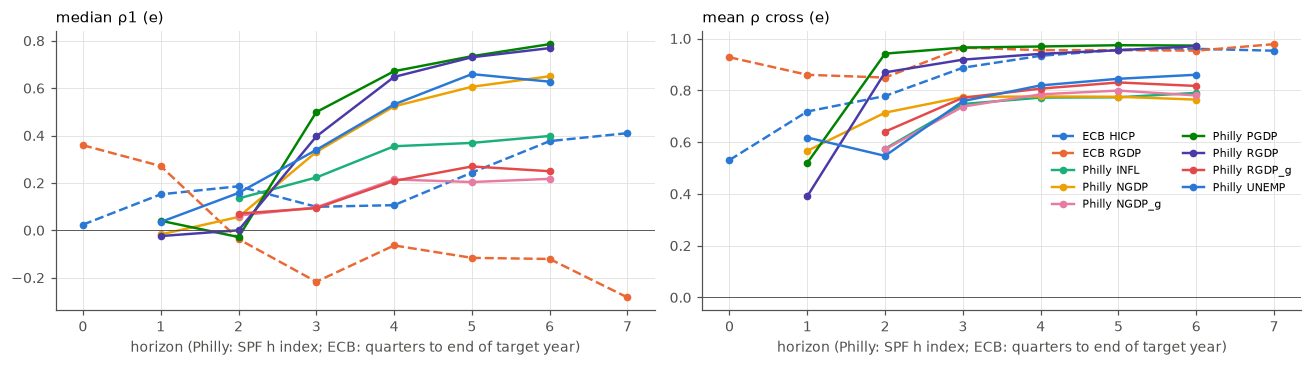

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.4))
for ax, metric in zip(axes, ["median ρ1 (e)", "mean ρ cross (e)"]):
    for name, g in sweep.groupby("panel"):
        ls = "-" if name.startswith("Philly") else "--"
        ax.plot(g.h, g[metric], ls, marker="o", ms=4, label=name)
    ax.axhline(0, color=INK2, lw=0.6)
    ax.set_xlabel("horizon (Philly: SPF h index; ECB: quarters to end of target year)")
    ax.set_title(metric, loc="left", fontsize=10)
axes[1].legend(frameon=False, fontsize=7, ncol=2)
fig.tight_layout()
plt.show()

## 5. Takeaways

Numbers quoted are from the run committed with this notebook. "Rates" means UNEMP, INFL, NGDP_g, RGDP_g, ECB HICP and ECB RGDP; "levels" means Philly NGDP, RGDP and PGDP.

**Cross-sectional correlation is strong in every panel.**
* The mean pairwise correlation of signed errors is 0.74–0.97. Pesaran CD is 140–300 against a N(0,1) null, so p ≈ 0 everywhere. A common period effect explains 74–98 % of the pooled error variance, against about 3 % if there were no common component.
* This is not driven by a few crises. Spearman correlations (0.67–0.91) and dropping 2020–21 (0.71–0.97) leave it almost unchanged.
* Squared losses are also strongly correlated: mean ρ(e²) is 0.58–0.97 (0.44–0.80 by Spearman). The $\hat\theta_j$ are therefore far from independent. The joint covariance (MDS $\Sigma$ / direct $\Omega$) is first-order, and an independence-based simulation would be badly miscalibrated.
* Differencing cancels most of it. 75–82 % of the loss variance cancels in $d^{jk}$ for the rate/growth panels, and 91–99 % for the level and ECB panels. The common shock mostly drops out of the comparisons the rank CIs are built on. What is left is the idiosyncratic part, which is what separates forecasters.

**Serial correlation is moderate in the rates and inflated in the levels.**
* Rates at h = 3: the median lag-1 ACF of signed errors is 0.09–0.34. For Philly this is in line with the MA(1) structure that one-quarter-ahead forecasts can have even under rational expectations. Beyond lag 2 the ACF is within the white-noise band.
* ECB annual (Q1 survey, current year): targets do not overlap, and with only T = 27 years almost nothing is significant (≤ 3.5 % of forecasters).
* Levels: lag-1 is 0.33–0.50, but much of this is mechanical. BEA rebasings or benchmark revisions hit two consecutive surveys with the same level shift (20 outlier quarters in RGDP, 10 in PGDP). The same forecasts in growth rates (`NGDP_g`, `RGDP_g`) give ρ1 ≈ 0.1 and have outliers only at COVID.
* Persistence grows with the horizon in the Philly panels. In levels, ρ1 rises from about 0 at h = 1–2 to 0.65–0.8 at h = 6; growth rates reach only about 0.2–0.25. Cross-sectional correlation also rises with the horizon, because longer-horizon errors load more on the common unforecastable shock.

**What the HAC actually faces.** The pairwise loss differentials are only mildly persistent. The median AR(1) is −0.13 to 0.27 and only INFL is clearly positive. The Andrews plug-in bandwidth is small (median L = 1–3.5, max 7). Bartlett HAC with a plug-in L is adequate, and serial dependence is a second-order issue next to the cross-sectional one.

**Implications for the analysis.**
1. Cross-sectional dependence is the main dependence problem. It justifies building the simulation covariance from the full pairwise structure rather than treating forecasters as independent.
2. The Philly level panels (NGDP / RGDP / PGDP) carry base-year artifacts. These show up as near-perfect cross-correlation, inflated lag-1 persistence and non-stationary loss variance. Ranking on growth rates (as `INFL` already does for PGDP) would remove them. Alternatively, keep levels and flag the comprehensive-revision quarters as a robustness check.
3. The ECB annual panels are short (T = 27), so the per-series serial-correlation evidence there has very low power.

## 6. Export for the thesis appendix

Writes the appendix tables (`thesis/tables/spf_dep_*.tex`) and figures (`thesis/figures/spf_dep_*.pdf`) from the
objects computed above, restricted to the panels reported in the applications chapter (U.S. NGDP, RGDP, UNEMP;
euro-area HICP, RGDP) plus the two growth-rate robustness panels. Skipped if the (git-ignored) `thesis/` folder is
not present.

In [22]:
from pathlib import Path

THESIS = Path("../thesis")
LABELS = {  # notebook panel -> thesis label (order = row order)
    "Philly NGDP": "U.S.\\ NGDP", "Philly RGDP": "U.S.\\ RGDP", "Philly UNEMP": "U.S.\\ UNEMP",
    "ECB HICP": "Euro area HICP", "ECB RGDP": "Euro area RGDP",
    "Philly NGDP_g": "U.S.\\ NGDP, growth$^\\dagger$", "Philly RGDP_g": "U.S.\\ RGDP, growth$^\\dagger$",
}
MAIN, ROBUST = list(LABELS)[:5], list(LABELS)[5:]


def _rows(fmt_row):
    body = [fmt_row(p) for p in MAIN] + ["    \\midrule"] + [fmt_row(p) for p in ROBUST]
    return "\n".join(body)


def _num(x, d=2):
    return "--" if pd.isna(x) else (f"${x:.{d}f}$" if x < 0 else f"{x:.{d}f}")


ser_e = serial_table(lambda x: x, "e")
ser_x = serial_table(lambda x: x ** 2, "x")
dstat = pd.DataFrame(tab).set_index("panel")
robt = pd.DataFrame(rob).set_index("panel")
ov = pd.DataFrame(overview).set_index("panel")

tex_panels = r'''\begin{table}[htb]
  \centering
  \caption[SPF error panels]{Error panels used in the dependence analysis. ``Forecasters'' counts those with at
  least 20 (U.S.) or 15 (euro area) observations; coverage is the share of non-missing cells among the eight
  best-covered forecasters, the panel the rank inference uses.}
  \label{tab:spf-dep-panels}
  \small
  \begin{tabular}{llrrr}
    \toprule
    panel & sample & periods & forecasters & top-8 coverage\\
    \midrule
''' + _rows(lambda p: f"    {LABELS[p]} & {ov.loc[p, 'span'].replace('–', '--')} & {ov.loc[p, 'T (grid)']} & "
                      f"{ov.loc[p, '≥ min_obs']} & {ov.loc[p, 'top-N coverage %']:.0f}\\%\\\\") + r'''
    \bottomrule
  \end{tabular}
\end{table}
'''

tex_serial = r'''\begin{table}[htb]
  \centering
  \caption[Serial dependence in SPF errors]{Serial dependence. Columns 2--5 are per-forecaster statistics over all
  forecasters in Table~\ref{tab:spf-dep-panels}: the median lag-1 autocorrelation of the signed error $e$ and of the
  loss $e^2$, the share of forecasters whose lag-1 autocorrelation lies outside the $\pm1.96/\sqrt{n_1}$ band, and the
  share rejecting the Box--Pierce test (4 lags U.S., 2 lags euro area) at 5\%. Columns 6--7 refer to the 28 pairwise
  loss differences $d^{jk}$ of the top-8 forecasters: the median AR(1) coefficient and the median Andrews bandwidth.
  Under no serial correlation about 5\% of forecasters would be flagged. $^\dagger$Robustness: the same forecasts
  as annualized quarter-on-quarter growth rates.}
  \label{tab:spf-dep-serial}
  \small
  \begin{tabular}{lcccccc}
    \toprule
    & \multicolumn{4}{c}{individual errors} & \multicolumn{2}{c}{loss differences}\\
    \cmidrule(lr){2-5}\cmidrule(lr){6-7}
    panel & $\hat\rho_1(e)$ & $\hat\rho_1(e^2)$ & lag-1 sig. & BP rej. & AR(1) of $d^{jk}$ & $\hat L$\\
    \midrule
''' + _rows(lambda p: f"    {LABELS[p]} & {_num(ser_e.loc[p, 'median ρ1'])} & {_num(ser_x.loc[p, 'median ρ1'])} & "
                      f"{ser_e.loc[p, '% ρ1 significant']:.0f}\\% & {ser_e.loc[p, '% BP p<0.05']:.0f}\\% & "
                      f"{_num(dstat.loc[p, 'median ρ(d)'])} & {dstat.loc[p, 'median L']:g}\\\\") + r'''
    \bottomrule
  \end{tabular}
\end{table}
'''

tex_cross = r'''\begin{table}[htb]
  \centering
  \caption[Cross-sectional dependence in SPF errors]{Cross-sectional dependence of the errors. Mean pairwise
  correlation of signed errors (Pearson and Spearman) and of losses $e^2$, over all forecaster pairs in
  Table~\ref{tab:spf-dep-panels} with at least eight common periods; Pesaran's CD statistic for the signed errors
  ($\approx\Normal(0,1)$ under cross-sectional independence); and the share of the pooled error variance explained
  by a common period effect, with its value under no common component in parentheses. $^\dagger$As in
  Table~\ref{tab:spf-dep-serial}.}
  \label{tab:spf-dep-cross}
  \small
  \begin{tabular}{lccccc}
    \toprule
    panel & $\bar\rho(e)$ & $\bar\rho_S(e)$ & $\bar\rho(e^2)$ & CD & period $R^2$\\
    \midrule
''' + _rows(lambda p: f"    {LABELS[p]} & {_num(cs_table.loc[p, 'mean ρ (e)'])} & {_num(robt.loc[p, 'mean ρ (e) Spearman'])} & "
                      f"{_num(cs_table.loc[p, 'mean ρ (e²)'])} & {cs_table.loc[p, 'CD (e)']:.0f} & "
                      f"{cs_table.loc[p, 'time-effect R²']:.2f} ({cs_table.loc[p, 'null R²']:.2f})\\\\") + r'''
    \bottomrule
  \end{tabular}
\end{table}
'''

tex_diff = r'''\begin{table}[htb]
  \centering
  \caption[The common shock in loss differences]{The common shock in the loss differences of the top-8
  forecasters. ``Cancelled'' is the median over pairs of $2\Cov(X_j,X_k)/(\Var X_j+\Var X_k)$, the share of the
  loss variance removed by differencing. The remaining columns relate the cross-pair mean of $(d^{jk}_t)^2$ to the
  squared consensus error $\bar e_t^{\,2}$: their Spearman correlation, and the share of $\sum_t (d^{jk}_t)^2$ that
  falls in the 10\% of periods with the largest $\bar e_t^{\,2}$, on the full sample and without 2020--21.
  $^\dagger$As in Table~\ref{tab:spf-dep-serial}.}
  \label{tab:spf-dep-diff}
  \small
  \begin{tabular}{lccccc}
    \toprule
    & & \multicolumn{2}{c}{$\rho_S\big(\bar e_t^{\,2},\,\overline{d_t^{\,2}}\big)$}
      & \multicolumn{2}{c}{share in top-10\% periods}\\
    \cmidrule(lr){3-4}\cmidrule(lr){5-6}
    panel & cancelled & full & ex-2020/21 & full & ex-2020/21\\
    \midrule
''' + _rows(lambda p: f"    {LABELS[p]} & {_num(cs_table.loc[p, 'top-N cancellation'])} & "
                      f"{_num(reentry.loc[p, 'Spearman(ē², mean d²)'])} & {_num(reentry_ex.loc[p, 'Spearman(ē², mean d²)'])} & "
                      f"{100 * reentry.loc[p, 'share of Σd² in shock periods']:.0f}\\% & "
                      f"{100 * reentry_ex.loc[p, 'share of Σd² in shock periods']:.0f}\\%\\\\") + r'''
    \bottomrule
  \end{tabular}
\end{table}
'''


def export_figures(fig_dir):
    # (a) errors over time
    fig, axes = plt.subplots(3, 2, figsize=(6.6, 6.2), squeeze=False)
    order = ["Philly NGDP", "ECB HICP", "Philly RGDP", "ECB RGDP", "Philly UNEMP"]
    for ax, p in zip(axes.flat, order):
        src, E = PANELS[p]
        t = E.index.to_timestamp()
        for c in top_n(E, src).columns:
            ax.plot(t, E[c], color="#9c9b97", lw=0.5, alpha=0.7)
        ax.plot(t, E.mean(axis=1), color=C1, lw=1.3)
        ax.axhline(0, color=INK2, lw=0.5)
        ax.set_title(LABELS[p].replace("\\ ", " "), loc="left", fontsize=9)
        ax.tick_params(labelsize=7)
    axes.flat[-1].set_visible(False)
    fig.tight_layout()
    fig.savefig(fig_dir / "spf_dep_errors.pdf", bbox_inches="tight")
    plt.close(fig)
    # (b) ACF profiles
    fig, axes = plt.subplots(3, 2, figsize=(6.6, 5.6), squeeze=False)
    for ax, p in zip(axes.flat, order):
        src, E = PANELS[p]
        for transform, colr, lab in [(lambda x: x, C1, "error $e$"), (lambda x: x ** 2, C2, "loss $e^2$")]:
            R, N = acf_matrix(E, src, transform)
            ax.fill_between(lags, np.nanpercentile(R, 25, axis=0), np.nanpercentile(R, 75, axis=0),
                            color=colr, alpha=0.15, lw=0)
            ax.plot(lags, np.nanmedian(R, axis=0), color=colr, marker="o", ms=3, lw=1.2, label=lab)
        band = 1.96 / np.sqrt(np.nanmedian(N[:, 0]))
        ax.axhspan(-band, band, color="#9c9b97", alpha=0.15, lw=0)
        ax.axhline(0, color=INK2, lw=0.5)
        ax.set_ylim(-0.6, 1); ax.set_xticks(lags); ax.tick_params(labelsize=7)
        ax.set_title(LABELS[p].replace("\\ ", " "), loc="left", fontsize=9)
    axes.flat[0].legend(frameon=False, fontsize=7)
    axes.flat[-1].set_visible(False)
    fig.supxlabel("lag (quarters for the U.S., years for the euro area)", fontsize=8)
    fig.tight_layout()
    fig.savefig(fig_dir / "spf_dep_acf.pdf", bbox_inches="tight")
    plt.close(fig)


if THESIS.exists():
    for name, tex in [("spf_dep_panels", tex_panels), ("spf_dep_serial", tex_serial),
                      ("spf_dep_cross", tex_cross), ("spf_dep_diff", tex_diff)]:
        (THESIS / "tables" / f"{name}.tex").write_text(tex)
    export_figures(THESIS / "figures")
    print("exported to", THESIS.resolve())
else:
    print("thesis/ not found; skipped export")
print(tex_panels, tex_serial, tex_cross, tex_diff, sep='\n')

exported to /Users/Parimah/Desktop/ranks-inference-forecasters/thesis
\begin{table}[htb]
  \centering
  \caption[SPF error panels]{Error panels used in the dependence analysis. ``Forecasters'' counts those with at
  least 20 (U.S.) or 15 (euro area) observations; coverage is the share of non-missing cells among the eight
  best-covered forecasters, the panel the rank inference uses.}
  \label{tab:spf-dep-panels}
  \small
  \begin{tabular}{llrrr}
    \toprule
    panel & sample & periods & forecasters & top-8 coverage\\
    \midrule
    U.S.\ NGDP & 1968Q4 -- 2025Q1 & 226 & 148 & 52\%\\
    U.S.\ RGDP & 1968Q4 -- 2025Q1 & 226 & 147 & 52\%\\
    U.S.\ UNEMP & 1968Q4 -- 2025Q3 & 228 & 151 & 52\%\\
    Euro area HICP & 1999 -- 2025 & 27 & 58 & 99\%\\
    Euro area RGDP & 1999 -- 2025 & 27 & 58 & 99\%\\
    \midrule
    U.S.\ NGDP, growth$^\dagger$ & 1968Q4 -- 2025Q1 & 226 & 148 & 52\%\\
    U.S.\ RGDP, growth$^\dagger$ & 1968Q4 -- 2025Q1 & 226 & 147 & 52\%\\
    \bottomrule
  \end{tabular}